In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.read_csv("wine_data.csv")

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [19]:
pd.read_csv("wine_data.csv",usecols=[0,1,2],header=None)

,0,1,2
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [10]:
pd.read_csv("wine_data.csv",usecols=[0,1,2])

,1,14.23,1.71
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76
...,...,...,...
172,3,13.71,5.65
173,3,13.40,3.91
174,3,13.27,4.28
175,3,13.17,2.59


In [3]:
wine_data_file=pd.read_csv("wine_data.csv",usecols=[0,1,2],names=["Class label","Alcohol","Malic acid"])

In [4]:
wine_data_file

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


In [5]:
wine_data_file.shape

(178, 3)

<Axes: xlabel='Alcohol', ylabel='Density'>

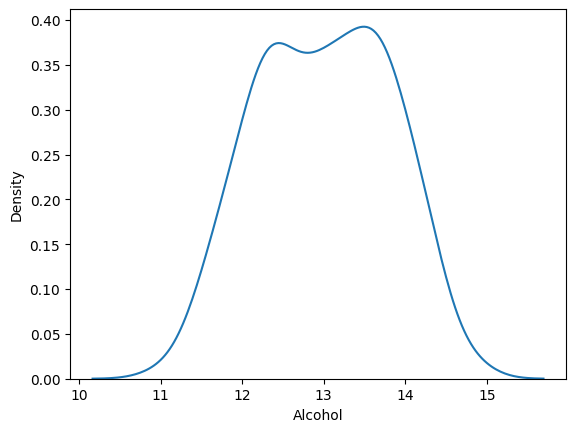

In [21]:
sns.kdeplot(data=wine_data_file,x="Alcohol")

<Axes: xlabel='Malic acid', ylabel='Density'>

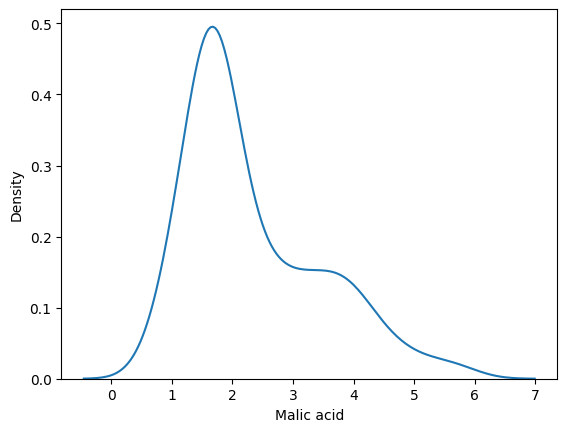

In [23]:
sns.kdeplot(data=wine_data_file,x="Malic acid")

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

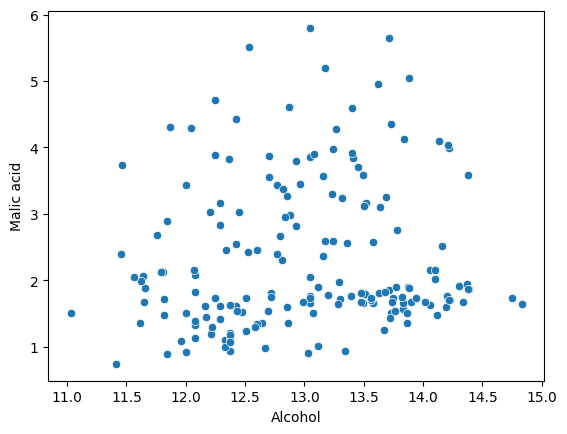

In [25]:
sns.scatterplot(data=wine_data_file,x="Alcohol",y="Malic acid")

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

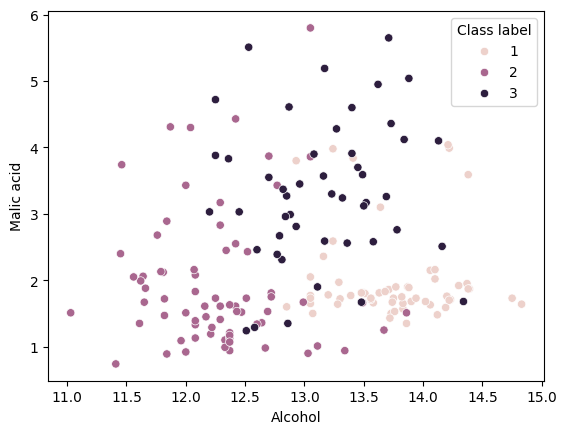

In [26]:
sns.scatterplot(data=wine_data_file,x="Alcohol",y="Malic acid",hue="Class label")

train_test_split

In [7]:
from sklearn.model_selection import train_test_split

x=wine_data_file[["Alcohol","Malic acid"]]
y=wine_data_file["Class label"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)



In [11]:
x_train

,Alcohol,Malic acid
22,13.71,1.86
108,12.22,1.29
175,13.27,4.28
145,13.16,3.57
71,13.86,1.51
...,...,...
103,11.82,1.72
67,12.37,1.17
117,12.42,1.61
47,13.90,1.68


In [13]:
x_test

,Alcohol,Malic acid
54,13.74,1.67
151,12.79,2.67
63,12.37,1.13
55,13.56,1.73
123,13.05,5.80
121,11.56,2.05
7,14.06,2.15
160,12.36,3.83
106,12.25,1.73
90,12.08,1.83


In [15]:
x_test.shape

(54, 2)

In [ ]:
# Normalization--->
# scaled data into fixed range.between (0&1)
# minmaxscaler

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

#here internally learn min max value and apply formula then transform the data

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# print(x_train_scaled) # here the problem is sklearn class convert it into numpy array and we want in dataframe so convert it inti dataframe

x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)


In [22]:
x_train_scaled

,Alcohol,Malic acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252
...,...,...
119,0.212366,0.174370
120,0.360215,0.058824
121,0.373656,0.151261
122,0.771505,0.165966


In [24]:
x_train.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,12.983065,2.383710
std,0.801340,1.136696
min,11.030000,0.890000
25%,12.362500,1.607500
50%,13.040000,1.885000
75%,13.640000,3.247500
max,14.750000,5.650000


In [26]:
x_train_scaled.describe()

,Alcohol,Malic acid
count,124.000000,124.000000
mean,0.525017,0.313805
std,0.215414,0.238802
min,0.000000,0.000000
25%,0.358199,0.150735
50%,0.540323,0.209034
75%,0.701613,0.495273
max,1.000000,1.000000


In [28]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [29]:
# scatter plot 


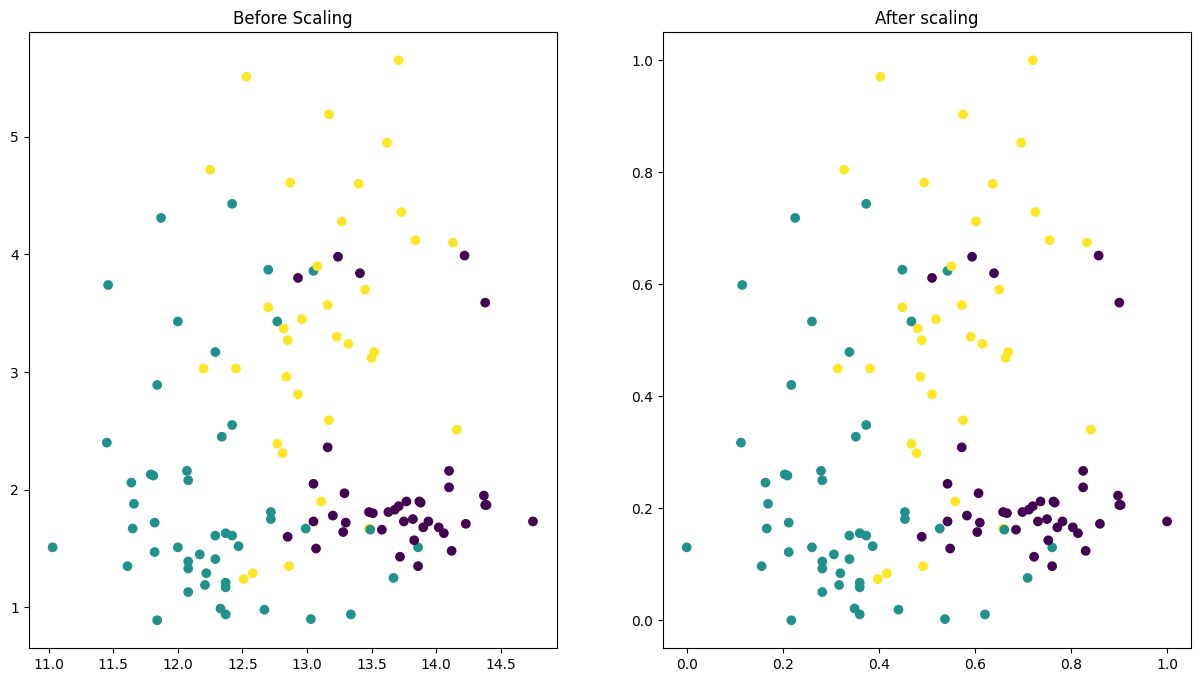

In [ ]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(15,8))

ax[0].set_title("Before Scaling")
ax[0].scatter(x_train["Alcohol"],x_train["Malic acid"],c=y_train)

ax[1].set_title("After scaling")
ax[1].scatter(x_train_scaled["Alcohol"],x_train_scaled["Malic acid"],c=y_train)


#no distribution change only scaled change..

In [35]:
#ALCOHOL DISTRIBUTION BEFORE scaling

<Axes: title={'center': 'Alcohol distribution after scaling'}, xlabel='Alcohol', ylabel='Density'>

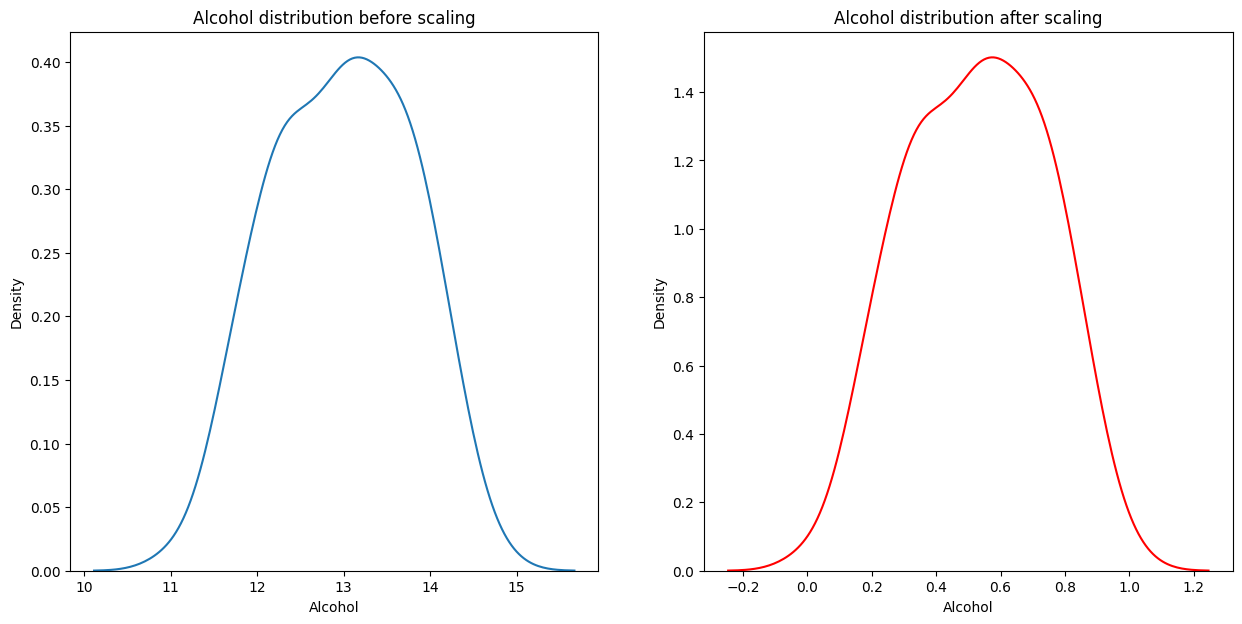

In [43]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(15,7))

ax[0].set_title("Alcohol distribution before scaling")
sns.kdeplot(data=x_train,x="Alcohol",ax=ax[0])

ax[1].set_title("Alcohol distribution after scaling")
sns.kdeplot(data=x_train_scaled,x="Alcohol",ax=ax[1],color="red")

In [44]:
#MALIC ACID DISTRIBUTION BEFORE & AFTER scaling

<Axes: title={'center': 'Malic acid distribution after scaling'}, xlabel='Malic acid', ylabel='Density'>

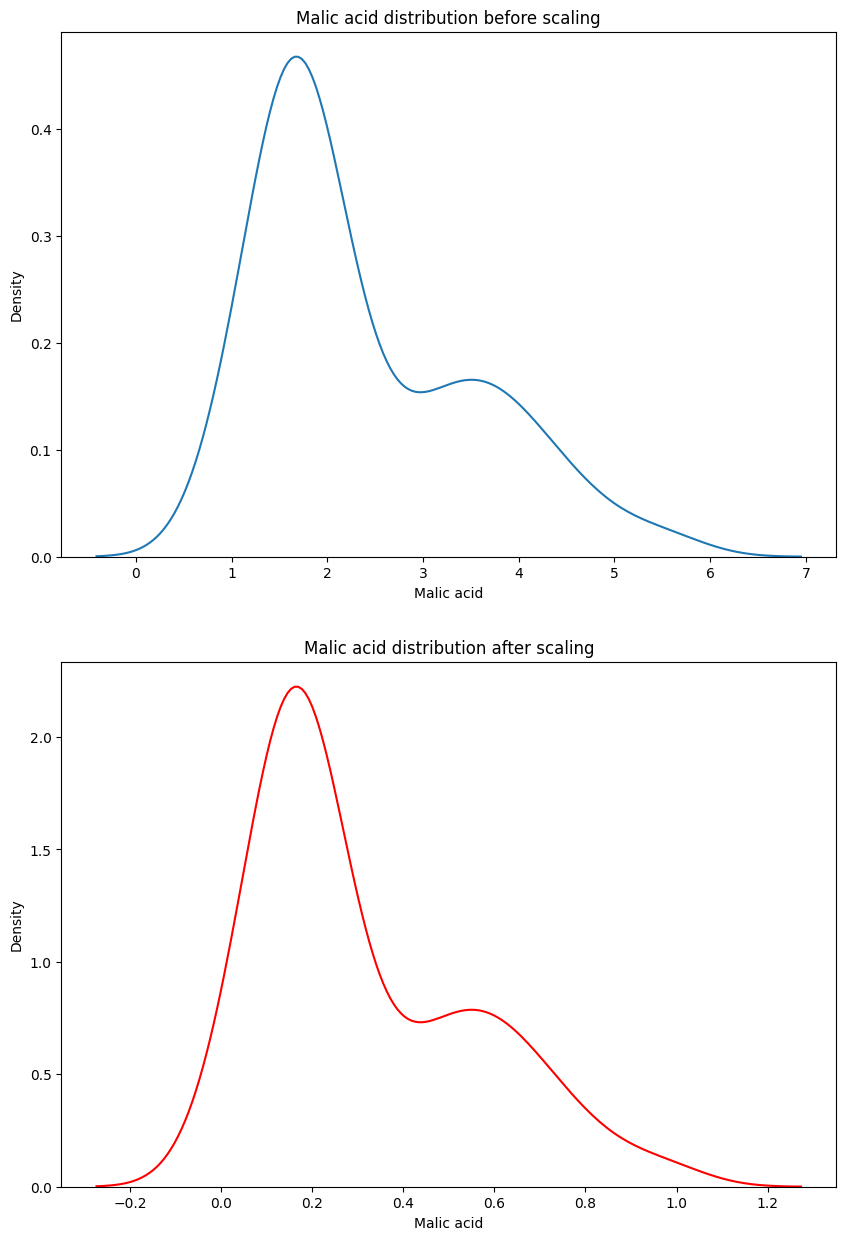

In [48]:
fig,ax=plt.subplots(nrows=2,ncols=1,figsize=(10,15))

ax[0].set_title("Malic acid distribution before scaling")
sns.kdeplot(data=x_train,x="Malic acid",ax=ax[0])

ax[1].set_title("Malic acid distribution after scaling")
sns.kdeplot(data=x_train_scaled,x="Malic acid",ax=ax[1],color="red")

<Axes: title={'center': 'After scaling'}, xlabel='Alcohol', ylabel='Density'>

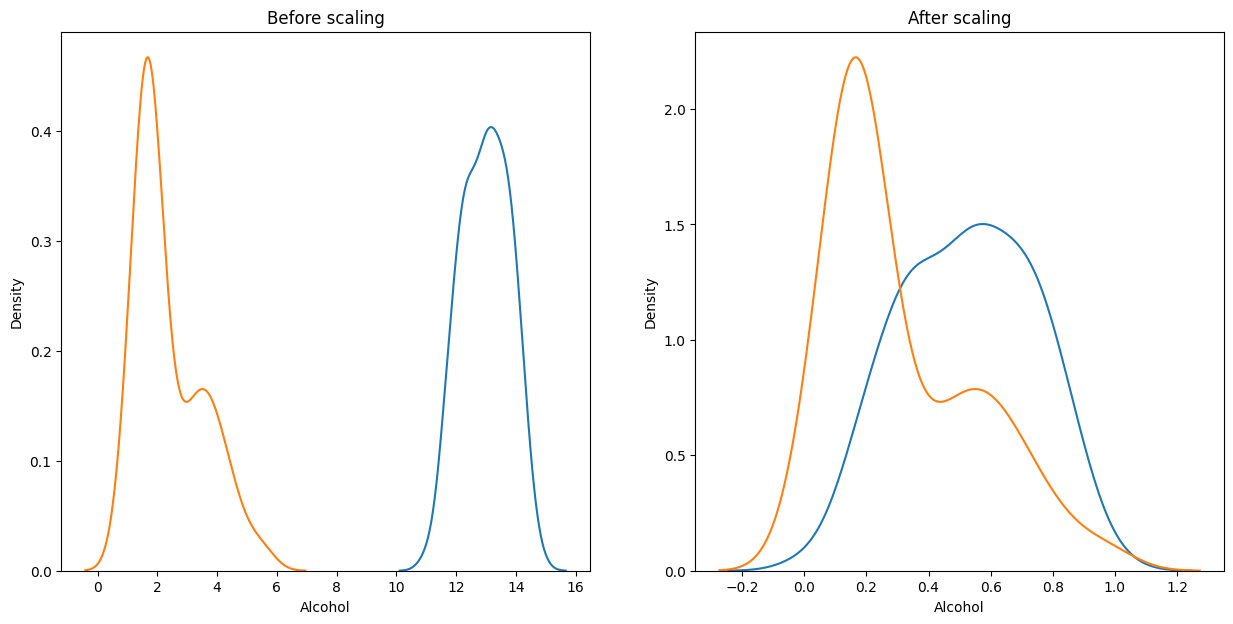

In [53]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(15,7))

ax[0].set_title("Before scaling")
sns.kdeplot(data=x_train,x="Alcohol",ax=ax[0])
sns.kdeplot(data=x_train,x="Malic acid",ax=ax[0])

ax[1].set_title("After scaling")
sns.kdeplot(data=x_train_scaled,x="Alcohol",ax=ax[1])
sns.kdeplot(data=x_train_scaled,x="Malic acid",ax=ax[1])

#here,we see that how alchol and malic acid ,after scaled come in same range 


In [61]:
wine_data_file.head(3)
# wine_data_file["Class label"].sample(6)
# wine_data_file["Alcohol"].sample(6)
wine_data_file["Malic acid"].sample(6)

85     0.98
163    3.45
136    4.72
134    1.24
63     1.13
57     1.97
Name: Malic acid, dtype: float64

In [62]:
#minmaxscaler is sensitive to outlier
wine_data_file
d={"Class label":[1,2,3],"Alcohol":[100.98,50.55,30.00],"Malic acid":[8.00,5.77,6.98]}
df=pd.DataFrame(d)

In [65]:
df

,Class label,Alcohol,Malic acid
0,1,100.98,8.00
1,2,50.55,5.77
2,3,30.00,6.98


In [68]:
df1=pd.concat([wine_data_file,df],ignore_index=True)

In [71]:
df1

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
176,3,13.17,2.59
177,3,14.13,4.10
178,1,100.98,8.00
179,2,50.55,5.77


In [73]:
df1.describe()

,Class label,Alcohol,Malic acid
count,181.000000,181.000000,181.000000
mean,1.939227,13.788066,2.412265
std,0.775785,7.243283,1.258937
min,1.000000,11.030000,0.740000
25%,1.000000,12.370000,1.610000
50%,2.000000,13.050000,1.870000
75%,3.000000,13.710000,3.170000
max,3.000000,100.980000,8.000000


In [75]:
from sklearn.model_selection import train_test_split

x=df1[["Alcohol","Malic acid"]]
y=df1["Class label"]

In [77]:
x_train_outlier,x_test_outlier,y_train_outlier,y_test_outlier=train_test_split(x,y,test_size=0.3,random_state=0)

In [109]:
x_train_outlier.sample(6)

,Alcohol,Malic acid
146,13.88,5.04
68,13.34,0.94
158,14.34,1.68
48,14.10,2.02
180,30.00,6.98
108,12.22,1.29


In [111]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

x_train_outlier_scaled=scaler.fit_transform(x_train_outlier)
x_test_outlier_scaled=scaler.transform(x_test_outlier)

In [114]:

x_train_outlier_scaled=pd.DataFrame(x_train_outlier_scaled,columns=x_train_outlier.columns)
x_test_outlier_scaled=pd.DataFrame(x_test_outlier_scaled,columns=x_test_outlier.columns)

In [116]:
x_train_outlier.describe()

,Alcohol,Malic acid
count,126.000000,126.000000
mean,13.417222,2.371667
std,3.752251,1.223539
min,11.030000,0.740000
25%,12.345000,1.615000
50%,13.040000,1.865000
75%,13.677500,3.030000
max,50.550000,6.980000


In [118]:
x_train_outlier_scaled.describe()

,Alcohol,Malic acid
count,126.000000,126.000000
mean,0.060405,0.261485
std,0.094946,0.196080
min,0.000000,0.000000
25%,0.033274,0.140224
50%,0.050860,0.180288
75%,0.066991,0.366987
max,1.000000,1.000000


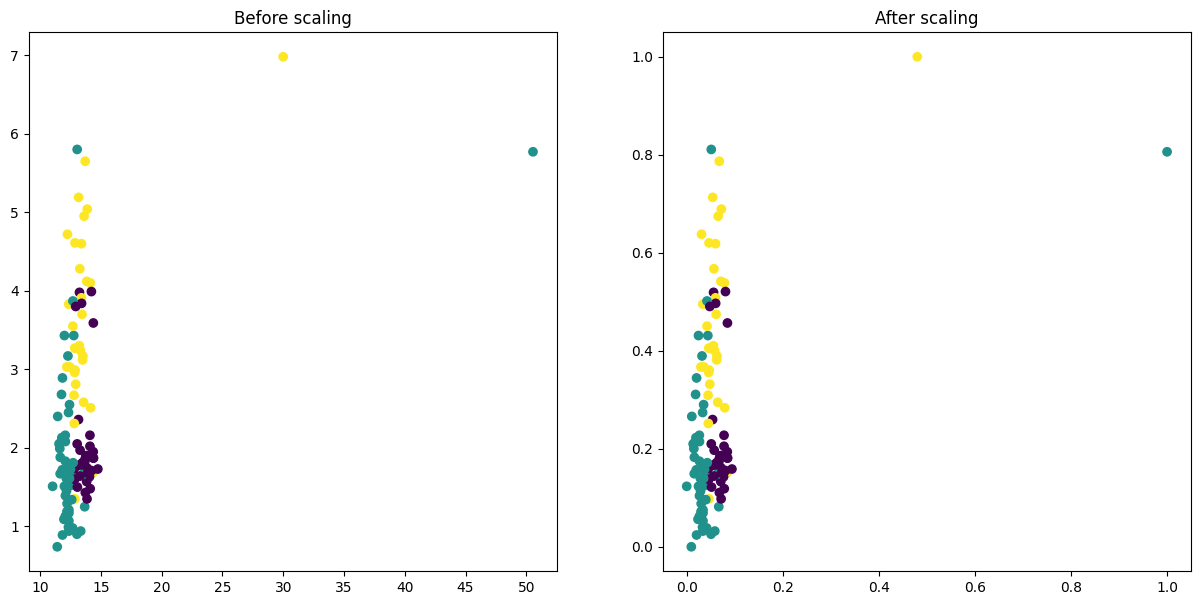

In [120]:
fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(15,7))
ax[0].set_title("Before scaling")
ax[0].scatter(x_train_outlier["Alcohol"],x_train_outlier["Malic acid"],c=y_train_outlier)
ax[1].set_title("After scaling")
ax[1].scatter(x_train_outlier_scaled["Alcohol"],x_train_outlier_scaled["Malic acid"],c=y_train_outlier)

In [121]:
#the if one value is big or small(outlier),it affect all other values,if max is huge everything becoome small.

#OUTLIER CONTROL THE SCALING